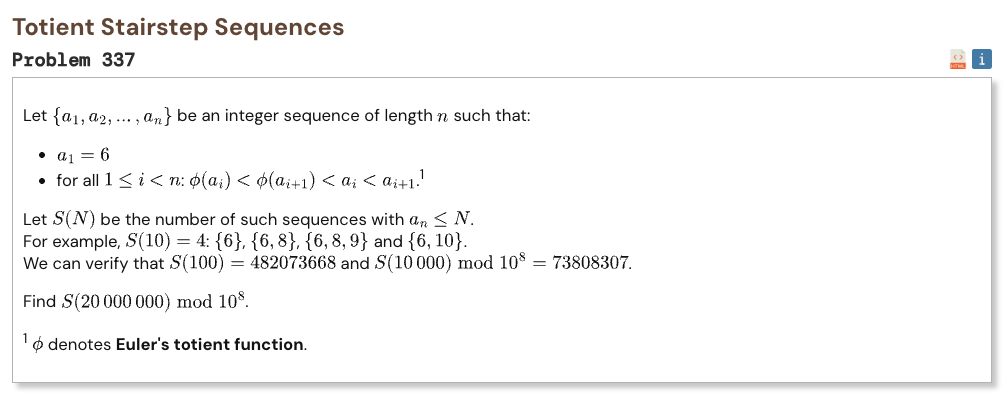

## Initial approach

* count sequences by their last value
* when a sequence ends at a, it can extend to any later b only if phi(b) lies between phi(a) and a
* so each finished value a adds its count to a range of possible future totient values
* use a Fenwick tree as a range-add and point-query structure
* process values from small to large, so the condition a < b is automatic
* first compute all totients with a sieve
* keep everything modulo the required value

In [1]:
MOD = 10 ** 8

class Fenwick:
    def __init__(self, size):
        self.size = size
        self.tree = [0] * (size + 2)

    def add(self, index, value):
        while index <= self.size:
            self.tree[index] = (self.tree[index] + value) % MOD
            index += index & -index

    def range_add(self, left, right, value):
        if left > right:
            return

        self.add(left, value)
        self.add(right + 1, -value)

    def point_query(self, index):
        total = 0

        while index > 0:
            total += self.tree[index]
            index -= index & -index

        return total % MOD

def totient_sieve(limit):
    phi = list(range(limit + 1))

    for i in range(2, limit + 1):
        if phi[i] == i:
            for j in range(i, limit + 1, i):
                phi[j] -= phi[j] // i

    return phi

def S(limit):
    phi = totient_sieve(limit)
    bit = Fenwick(limit)
    total = 0

    for n in range(1, limit + 1):
        if n == 6:
            count = 1
        else:
            count = bit.point_query(phi[n])

        total = (total + count) % MOD

        if count:
            bit.range_add(phi[n] + 1, n - 1, count)

    return total

assert S(10) == 4
assert S(100) == 482073668 % MOD
assert S(10000) == 73808307

In [2]:
%%time
result = S(20_000_000)
print("Result:", result)

Result: 85068035
CPU times: user 1min 47s, sys: 2.22 s, total: 1min 50s
Wall time: 1min 52s
